# LeetCode #198: House Robber

https://leetcode.com/problems/house-robber/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Recursive (brute force)** | $O(2^n)$ | $O(n)$ |
| **DP with array** | $O(n)$ | $O(n)$ |
| **Optimal: DP with two variables** | $O(n)$ | $O(1)$ |

---

## Understanding the Methods

### Recursive
At each house, either rob it (add its value and skip the next) or skip it. Try both and take the maximum. Without memoization this is $O(2^n)$ due to overlapping subproblems.

### DP with Array
Define `dp[i]` as the maximum money robbing houses `0..i`. Recurrence: `dp[i] = max(dp[i-1], dp[i-2] + nums[i])`. Either skip house `i` (take `dp[i-1]`) or rob it (take `dp[i-2] + nums[i]`). Uses $O(n)$ space.

### Optimal: DP with Two Variables ★
Since `dp[i]` only depends on `dp[i-1]` and `dp[i-2]`, we only need two variables:
- `prev2` = best up to two houses ago
- `prev1` = best up to the previous house

At each house: `curr = max(prev1, prev2 + nums[i])`, then shift: `prev2 = prev1`, `prev1 = curr`.

**Why this works:** The no-adjacent constraint means each decision depends on at most two prior states. Rolling two variables forward captures the full DP in $O(1)$ space.

**Constraints:**
* `1 <= nums.length <= 100`
* `0 <= nums[i] <= 400`

## Solutions

### C#

In [ ]:
public class Solution {
    public int Rob(int[] nums) {
        int prev2 = 0, prev1 = 0;
        
        foreach (int num in nums) {
            int curr = Math.Max(prev1, prev2 + num);
            prev2 = prev1;
            prev1 = curr;
        }
        
        return prev1;
    }
}

### Python

In [ ]:
class Solution:
    def rob(self, nums: list[int]) -> int:
        prev2 = prev1 = 0
        
        for num in nums:
            curr = max(prev1, prev2 + num)
            prev2 = prev1
            prev1 = curr
        
        return prev1

### Go

In [ ]:
func rob(nums []int) int {
    prev2, prev1 := 0, 0
    
    for _, num := range nums {
        curr := prev1
        if prev2+num > curr {
            curr = prev2 + num
        }
        prev2 = prev1
        prev1 = curr
    }
    
    return prev1
}

### Rust

In [ ]:
impl Solution {
    pub fn rob(nums: Vec<i32>) -> i32 {
        let (mut prev2, mut prev1) = (0, 0);
        
        for &num in &nums {
            let curr = prev1.max(prev2 + num);
            prev2 = prev1;
            prev1 = curr;
        }
        
        prev1
    }
}

## Examples

**1. Common Case**
**Input:** `nums = [1, 2, 3, 1]`
Rob houses 0 and 2: $1 + 3 = 4$. Cannot rob adjacent houses. DP trace: prev2/prev1 roll forward as $\text{curr} = \max(\text{prev1}, \text{prev2} + \text{nums}[i])$.
*Why tricky:* Baseline DP — the recurrence $\max(\text{prev1}, \text{prev2} + \text{nums}[i])$ captures rob-or-skip at each step. Answer: $4$.

**2. Slightly Complex — Greedy Fails**
**Input:** `nums = [2, 7, 9, 3, 1]`
Greedy would pick house 2 (value 9), but optimal is houses 0, 2, 4: $2 + 9 + 1 = 12$. Alternative: houses 1, 3: $7 + 3 = 10$. DP correctly finds 12.
*Why tricky:* Greedy on largest single value fails. DP explores all valid subsets implicitly: $2^5 = 32$ possible subsets reduced to 5 DP steps.

**3. Edge Case: Time Factor — Maximum Length ($n = 100$)**
**Input:** `nums = [400, 400, ..., 400]` — 100 houses, all value 400
DP runs exactly 100 iterations, each $O(1)$. Brute force: $2^{100} \approx 10^{30}$ subsets — infeasible. Optimal: rob every other house → $50 \times 400 = 20{,}000$.
*Why tricky:* Max constraint $n = 100$. Even brute force $2^{100}$ is infeasible; DP reduces to $O(n) = 100$ steps.

**4. Edge Case: Space Factor — O(1) vs O(n)**
**Input:** `nums = [1, 2, 3, ..., 100]`
DP array: `dp[0..99]` = 100 integers = 400 bytes. Two-variable approach: `prev2, prev1` = 8 bytes. Savings: 98%. The rolling-variable optimization works because $dp[i]$ depends only on $dp[i-1]$ and $dp[i-2]$.
*Why tricky:* Space optimization from $O(n)$ to $O(1)$ — only two prior states matter. Classic sliding-window DP pattern.

**5. Almost-Impossible but Plausible — Maximum Possible Answer**
**Input:** `nums = [400, 0, 400, 0, ..., 400, 0]` — 100 elements, alternating 400 and 0
Rob all even-indexed houses: $50 \times 400 = 20{,}000$. Max possible answer given constraints. Check: $20{,}000 < 2^{31}-1 = 2{,}147{,}483{,}647$. No overflow.
*Why tricky:* Boundary value: $\lceil n/2 \rceil \times \max\_val = 50 \times 400 = 20{,}000$. Fits in 32-bit int — no overflow risk.

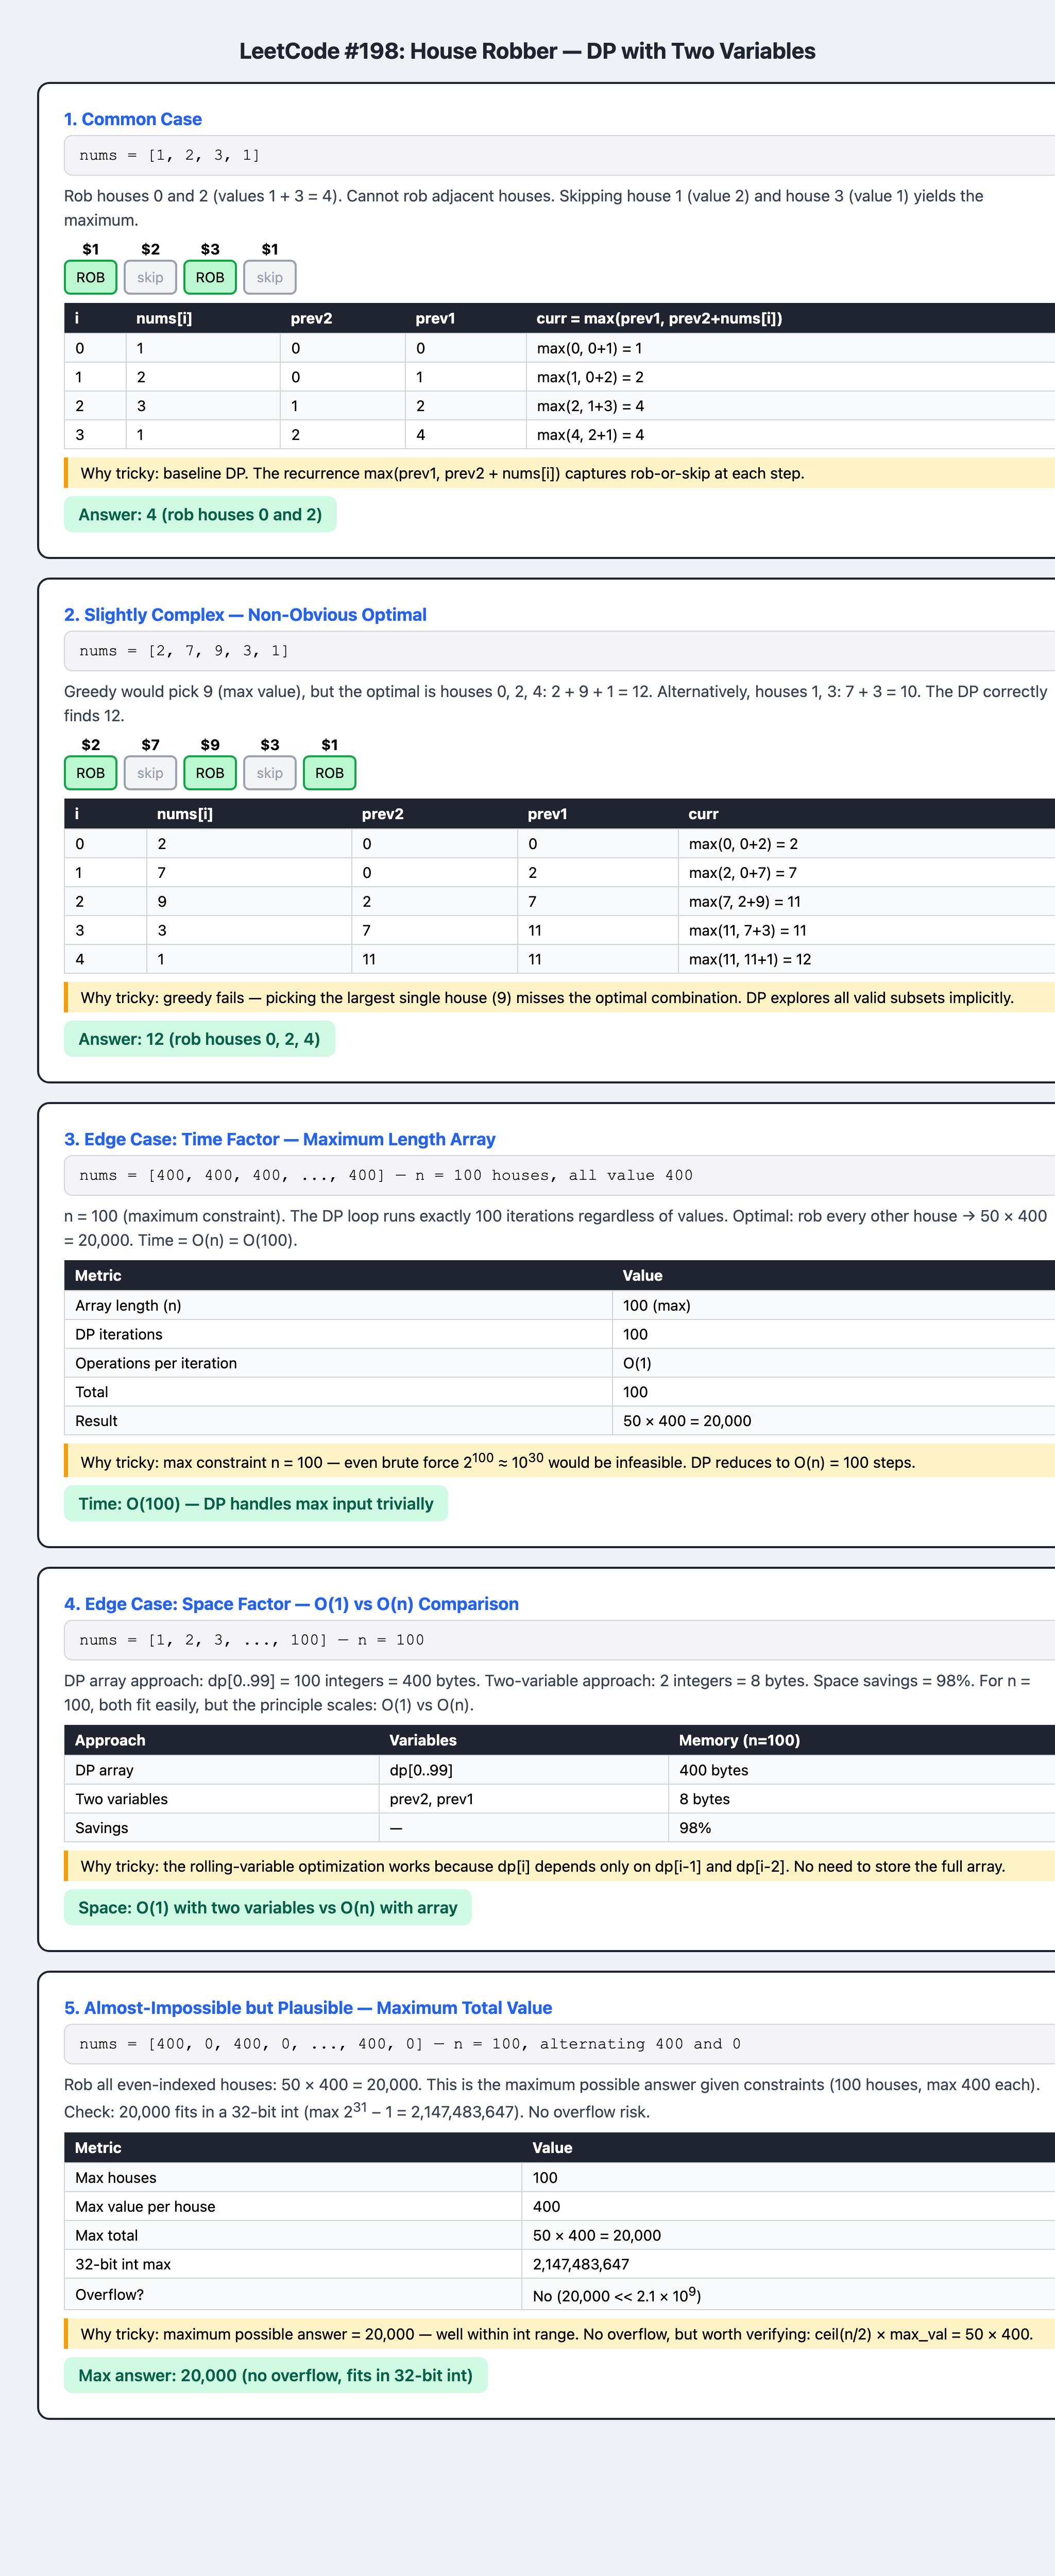